# SIOC 251: Homework 2
## Simulating the Radiative Forcing of Well-Mixed Gasses in the LW
**Author:** Sophie Wynn  
**Course:** SIOC 251 – Radiative Transfer  
**Date:** May 6th 2026

---
## Part I: Weighting Function

### Setup

A well-mixed gas with extinction coefficient:
$$\beta_e(z) = C\,e^{-z/H}$$
where $C$ is a gas concentration coefficient and $H$ is the atmospheric scale height.

### 1. Optical Depths

**$\tau(z)$** — optical depth from height $z$ to the top of atmosphere:
$$\tau(z) = \int_z^\infty \beta_e(z')\,dz' = \int_z^\infty C\,e^{-z'/H}\,dz' = CH\,e^{-z/H}$$

**$\tau^*$** — total optical depth of the atmosphere:
$$\tau^* = \tau(0) = CH$$

### 2. Flux Transmittance from $z$ to TOA

The flux transmittance uses the diffusivity factor $r$:
$$t_F(z,\infty) = e^{-r\,\tau(z)} = \exp\!\left(-r\,C\,H\,e^{-z/H}\right)$$

### 3. Upwelling Flux Weighting Function $W^\uparrow_F(z)$

The weighting function is the derivative of the flux transmittance with respect to altitude:
$$W^\uparrow_F(z) = \frac{d\,t_F(z,\infty)}{dz}$$

Taking the derivative:
$$W^\uparrow_F(z) = r\,C\,e^{-z/H}\;\exp\!\left(-r\,C\,H\,e^{-z/H}\right)$$

This is the product of:
- the local extinction $r\,C\,e^{-z/H}$ (how much the layer emits), and
- the transmittance to space $\exp(-r\,C\,H\,e^{-z/H})$ (how much escapes to TOA).

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'figure.dpi': 120,
})

print('Imports complete.')

Imports complete.


In [ ]:
# --- Physical parameters ---
H = 8500.0           # scale height (m)
r = 5.0 / 3.0        # diffusivity factor
C0 = 1.25e-4          # base gas concentration coefficient (m^-1)
z_toa = 200e3        #toa length
z = np.linspace(0, z_toa, 20000)

# --- Define functions ---

def tau(z, C, H):
    """Optical depth from height z to infinity."""
    return C * H * np.exp(-z / H)

def tau_star(C, H):
    """Total optical depth of the atmosphere."""
    return C * H

def flux_transmittance(z, C, H, r):
    """Flux transmittance from z to TOA."""
    return np.exp(-r * tau(z, C, H))

def weighting_function(z, C, H, r): 
    """Upwelling flux weighting function W_F(z)."""
    return r * C * np.exp(-z / H) * np.exp(-r * C * H * np.exp(-z / H))

### 4. Plot $W^\uparrow_F(z)$ for $f$ = 0.001, 0.01, 0.1, 1, 10, 100

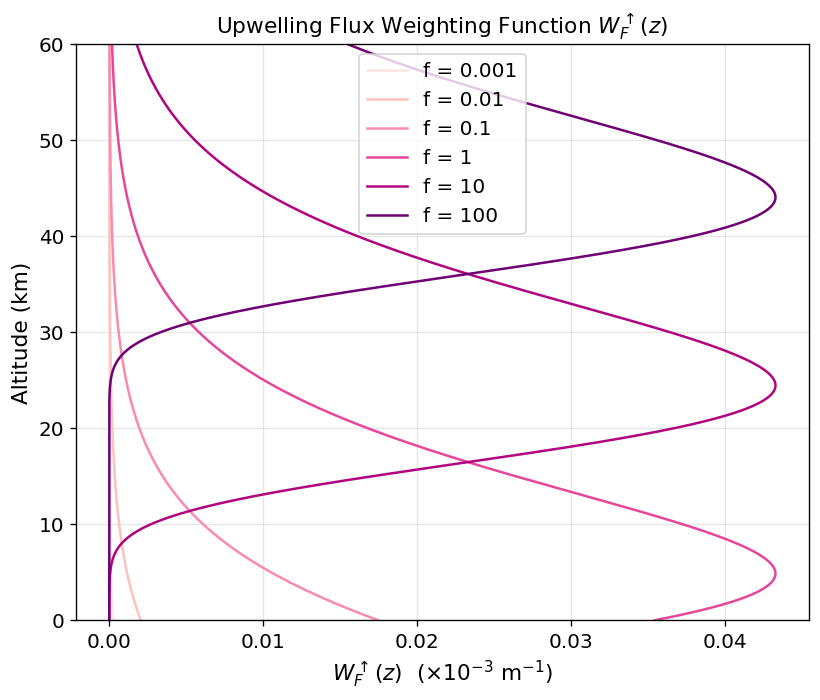

       f      C (m^-1)      tau*    r*tau*
--------------------------------------------
   0.001      1.25e-07     0.001     0.002
    0.01      1.25e-06     0.011     0.018
     0.1      1.25e-05     0.106     0.177
       1      1.25e-04     1.062     1.771
      10      1.25e-03    10.625    17.708
     100      1.25e-02   106.250   177.083


In [31]:
f_values = [0.001, 0.01, 0.1, 1, 10, 100]
colors = plt.cm.RdPu(np.linspace(0.1, 0.9, len(f_values)))

fig, ax = plt.subplots(figsize=(7, 6))

for f, col in zip(f_values, colors):
    C = f * C0
    W = weighting_function(z, C, H, r)
    ax.plot(W * 1e3, z / 1e3, color=col, lw=1.5, label=f'f = {f}')

ax.set_xlabel(r'$W^\uparrow_F(z)$  ($\times 10^{-3}$ m$^{-1}$)')
ax.set_ylabel('Altitude (km)')
ax.set_title(r'Upwelling Flux Weighting Function $W^\uparrow_F(z)$')
ax.legend()
ax.set_ylim(0, 60)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure1.png', bbox_inches='tight')
plt.show()

# Print tau* for each f value
print(f"{'f':>8}  {'C (m^-1)':>12}  {'tau*':>8}  {'r*tau*':>8}")
print('-' * 44)
for f in f_values:
    C = f * C0
    ts = tau_star(C, H)
    print(f"{f:>8g}  {C:>12.2e}  {ts:>8.3f}  {r*ts:>8.3f}")

### 4. How does W↑F(z) change for f = 0.001, 0.01, 0.1, 1, 10, 100?
- As the gas concentration increases the weighting function's peak moves up in the atmosphere. This means that most of the upwelling radiation is comming from higher altitudes which makes sense becuase the radiation that actually makes it out to the TOA has to originate from higher up. Also for very small f the weighting function is weak and peaked near the surface; for larger  f's it's peak has the same values in the x direction. 

### 5. How would your changes in W↑F(z) affect the TOA outgoing LW radiation?
- As the weighting fuction's peak increases with height, I think less total radiation would be leaving the atmosphere, if OLR is a function of Temperature ie Plank Function then at higher altitudes less LW outgoing radiation is leaving.B(T) decreases with decreasing T, so if the emission is coming from colder layers, the flux is smaller.





---
## Part II: TOA Outgoing LW Radiation

### 1. Upwelling Monochromatic Flux at TOA

From the Schwarzschild equation adapted for flux (Module 4 notes, eq. 14 $\to$ flux form), the upwelling monochromatic flux at the TOA is:

$$F^\uparrow_\lambda(\infty) = \pi B_\lambda(T_s)\,t_F(0,\infty) + \int_0^\infty \pi B_\lambda[T(z)]\,W^\uparrow_F(z)\,dz$$

where:
- $\pi B_\lambda(T_s)\,t_F(0,\infty)$ is the surface emission where $t_F(0,\infty) = e^{-r\tau^*} = e^{-rCH}$
- The integral is the atmospheric emission from each layer, weighted by how much escapes to TOA

### 2. Net Flux at TOA

There is no incoming longwave radiation at the TOA, so $F^\downarrow_\lambda(\infty) = 0$. The net flux is:

$$F_{n,\lambda}(\infty) = F^\uparrow_\lambda(\infty) - F^\downarrow_\lambda(\infty) = F^\uparrow_\lambda(\infty)$$

### Radiative Forcing

The radiative forcing is defined as:

$$\Delta F(\infty; f) = F_{n,\lambda}(\infty; f) - F_{n,\lambda}(\infty; f=0)$$

Since $F_{n,\lambda}(\infty) = F^\uparrow_\lambda(\infty)$, we can substitute:

$$\Delta F(\infty; f) = F^\uparrow_\lambda(\infty; f) - F^\uparrow_\lambda(\infty; f=0)$$

Now evaluate $F^\uparrow_\lambda(\infty; f=0)$. When $f = 0$ there is no absorbing gas, so $C = 0$, which gives $\tau^* = CH = 0$, $t_F(0,\infty) = e^{0} = 1$, and $W^\uparrow_F(z) = 0$ everywhere. Substituting into the expression for $F^\uparrow_\lambda$:

$$F^\uparrow_\lambda(\infty; f=0) = \pi B_\lambda(T_s) \cdot 1 + \int_0^\infty \pi B_\lambda[T(z)] \cdot 0\,dz = \pi B_\lambda(T_s)$$

So:

$$\Delta F(\infty; f) = F^\uparrow_\lambda(\infty; f) - \pi B_\lambda(T_s)$$

Substituting the full expression for $F^\uparrow_\lambda(\infty; f)$:

$$\Delta F(\infty; f) = \left[\pi B_\lambda(T_s)\,e^{-rCH} + \int_0^\infty \pi B_\lambda[T(z)]\,W^\uparrow_F(z)\,dz\right] - \pi B_\lambda(T_s)$$

$$\Delta F(\infty; f) = -\pi B_\lambda(T_s)\left[1 - e^{-rCH}\right] + \int_0^\infty \pi B_\lambda[T(z)]\,W^\uparrow_F(z)\,dz$$

where $C = f \times 1.25 \times 10^{-4}$ m$^{-1}, and.  $W^\uparrow_F(z) = r\,C\,e^{-z/H}\;\exp\!\left(-r\,C\,H\,e^{-z/H}\right)$


In [32]:
# --- Physical constants ---
h_planck = 6.626e-34    # Planck constant (J s)
c_light  = 3.0e8        # speed of light (m/s)
k_B      = 1.381e-23    # Boltzmann constant (J/K)

lam = 15e-6             # wavelength (m) — 15 micron
T_s = 300.0             # surface temperature (K)
Gamma = 5e-3            # tropospheric lapse rate (K/m) = 5 K/km

def planck(lam, T):
    """Planck function B_lambda(T) in W m^-2 sr^-1 m^-1."""
    return (2 * h_planck * c_light**2 / lam**5) / (np.exp(h_planck * c_light / (lam * k_B * T)) - 1)

# --- Temperature profiles ---

def T_profile_1(z):
    """Profile 1: T = 300 - 5z (z <= 20km), T = 200 K above."""
    T = np.where(z <= 20e3, T_s - Gamma * z, 200.0)
    return T

def T_profile_2(z):
    """Profile 2: Troposphere + stratospheric warming + isothermal above 50 km."""
    T = np.empty_like(z)
    Gamma_s = 2e-3    # stratospheric lapse rate (K/m)
    mask1 = z <= 20e3
    mask2 = (z > 20e3) & (z <= 50e3)
    mask3 = z > 50e3
    T[mask1] = T_s - Gamma * z[mask1]
    T[mask2] = 200 + Gamma_s * z[mask2]
    T[mask3] = 260
    return T

def T_isothermal(z):
    """Profile 3: Isothermal atmosphere T = 300 K."""
    return np.full_like(z, T_s)

print('Functions defined.')

Functions defined.


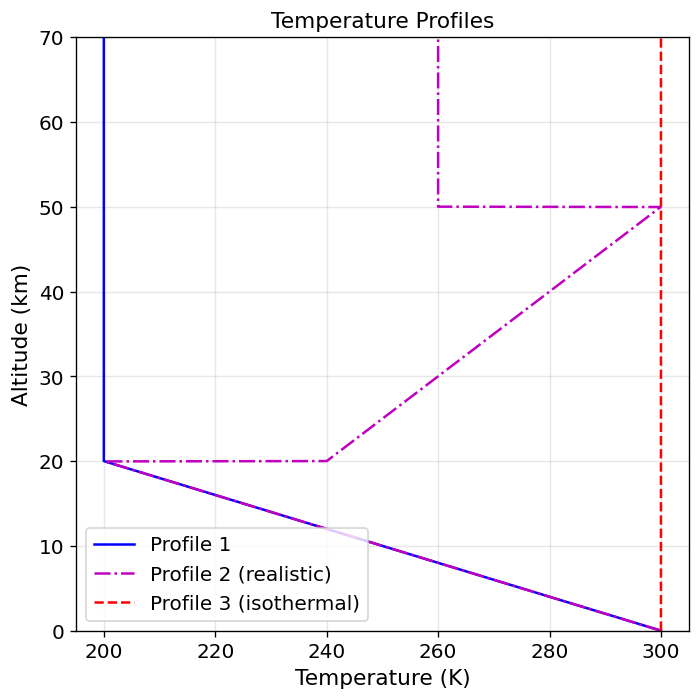

In [33]:
# --- Plot temperature profiles ---
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(T_profile_1(z), z / 1e3, 'b-',  lw=1.5, label='Profile 1')
ax.plot(T_profile_2(z), z / 1e3, 'm-.',  lw=1.5, label='Profile 2 (realistic)')
ax.plot(T_isothermal(z), z / 1e3, 'r--', lw=1.5, label='Profile 3 (isothermal)')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Temperature Profiles')
ax.set_ylim(0, 70)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/temperature_profiles.png', bbox_inches='tight')
plt.show()

In [34]:
def compute_F_up(z, C, H, r, lam, T_profile_func):
    """
    Compute upwelling monochromatic flux at TOA.
    
    F_up(inf) = pi * B(T_s) * t_F(0, inf)  +  integral[ pi * B(T(z)) * W(z) dz ]
    """
    T_z = T_profile_func(z)
    
    # Surface contribution
    tF_total = np.exp(-r * tau_star(C, H))  # t_F(0, inf)
    surface_term = np.pi * planck(lam, T_s) * tF_total
    
    # Atmospheric contribution
    W = weighting_function(z, C, H, r)
    B_z = planck(lam, T_z)
    atm_term = np.trapz(np.pi * B_z * W, z)
    
    return surface_term + atm_term


def compute_Fn_and_deltaF(f_array, T_profile_func):
    """
    Compute both F_n(inf; f) and Delta F(inf; f) for an array of f values.
    
    F_n(inf; f) = F_up(inf; f)     [since F_down(inf) = 0]
    Delta F     = F_n(f) - F_n(f=0) = F_up(f) - pi*B(T_s)
    """
    F_up_clear = np.pi * planck(lam, T_s)  # f=0: no gas, full surface emission
    
    F_n = np.zeros_like(f_array, dtype=float)
    delta_F = np.zeros_like(f_array, dtype=float)
    for i, f in enumerate(f_array):
        C = f * C0
        F_up_f = compute_F_up(z, C, H, r, lam, T_profile_func)
        F_n[i] = F_up_f
        delta_F[i] = F_up_f - F_up_clear
    
    return F_n, delta_F

print('Functions defined.')
print(f'Clear-sky flux pi*B(T_s) at 15 um: {np.pi * planck(lam, T_s):.4f} W/m^2/m')

Functions defined.
Clear-sky flux pi*B(T_s) at 15 um: 20997175.5095 W/m^2/m


### Temperature Profile 1
$$T(z) = \begin{cases} 300 - 5 z & z \leq 20\text{ km} \\ 200\text{ K} & z > 20\text{ km} \end{cases}$$


/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_34829/3189641021.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  atm_term = np.trapz(np.pi * B_z * W, z)
/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_34829/2151679199.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10)


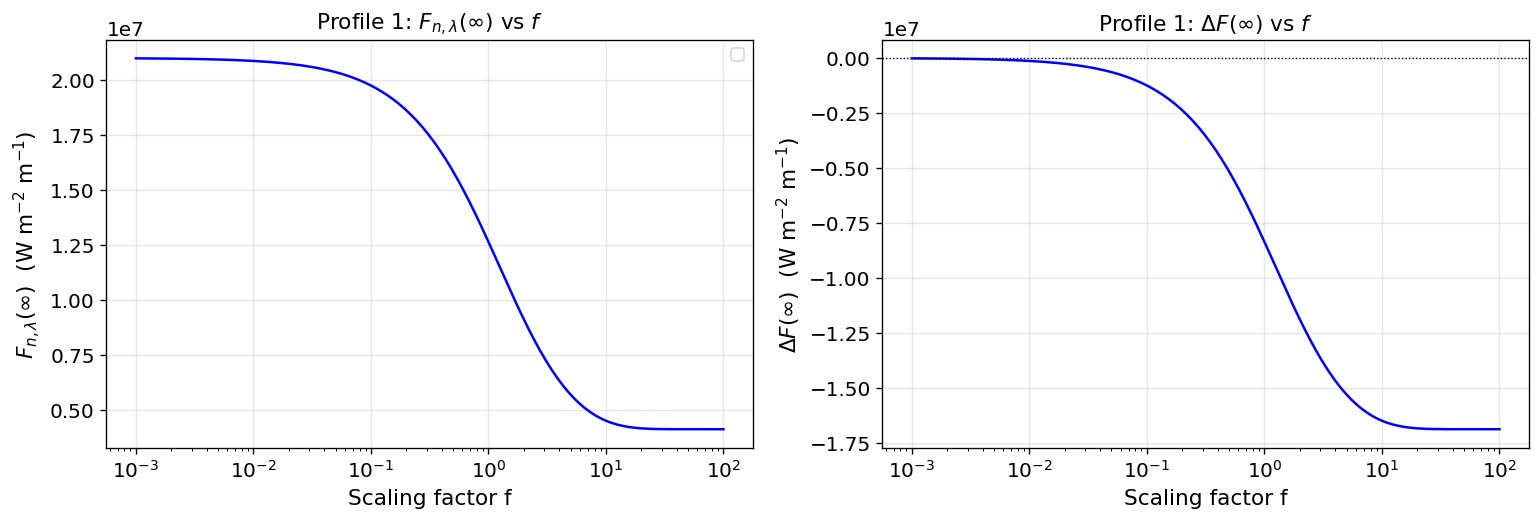

In [39]:
f_sweep = np.logspace(-3, 2, 200)

# 3. Calculate F_n and Delta F for all f
Fn_1, dF_1 = compute_Fn_and_deltaF(f_sweep, T_profile_1)
F_clear = np.pi * planck(lam, T_s)

# Plot both F_n(f) and Delta F(f) side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: F_n(inf) vs f
ax1.plot(f_sweep, Fn_1, 'b-', lw=1.5)
ax1.set_xscale('log')
ax1.set_xlabel('Scaling factor f')
ax1.set_ylabel(r'$F_{n,\lambda}(\infty)$  (W m$^{-2}$ m$^{-1}$)')
ax1.set_title(r'Profile 1: $F_{n,\lambda}(\infty)$ vs $f$')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Delta F vs f
ax2.plot(f_sweep, dF_1, 'b-', lw=1.5)
ax2.axhline(0, color='k', ls=':', lw=0.8)
ax2.set_xscale('log')
ax2.set_xlabel('Scaling factor f')
ax2.set_ylabel(r'$\Delta F(\infty)$  (W m$^{-2}$ m$^{-1}$)')
ax2.set_title(r'Profile 1: $\Delta F(\infty)$ vs $f$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/profile1.png', bbox_inches='tight')
plt.show()

**3. $F_{n,\lambda}(\infty)$ for all values of $f$:**

$F_{n,\lambda}(\infty)$  represents the outgoing LW radiation, for small f's ie less absorbing gas there is more OLR and for larger values of f there is less OLR. The plot above on the left shows $F_{n,\lambda}(\infty)$ for all values of $f$. 


**5. Explain the shape of $\Delta F(\infty)$ in terms of changes in $W^\uparrow_F(z)$ and $T(z)$:**

ΔF(∞; f)is just how much F_n changed relative to clear sky. As stated before the weighting function's peak increases in height with larger values of F. Also here in the temperature profile the temperature decreases at a constant laspe rate and then stays constant. As the weighting function's peak increases there is a greater difference in forcing from the gas concreation compared to the clear sky concentration. I also mentioned the relationship between OLR and emission temperature, since the temperature is constant after 20km I think as the weighting function's peak increases with hieght there would be less change in emmision since above 20km the atmosphere is isothermal. 



### Temperature Profile 2 
$$T(z) = \begin{cases} 300 - \Gamma z & z \leq 20\text{ km} \\ 200 + \Gamma_s z & 20 < z \leq 50\text{ km} \\ 260\text{ K} & z > 50\text{ km} \end{cases}$$

/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_34829/3189641021.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  atm_term = np.trapz(np.pi * B_z * W, z)
/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_34829/189108405.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10)


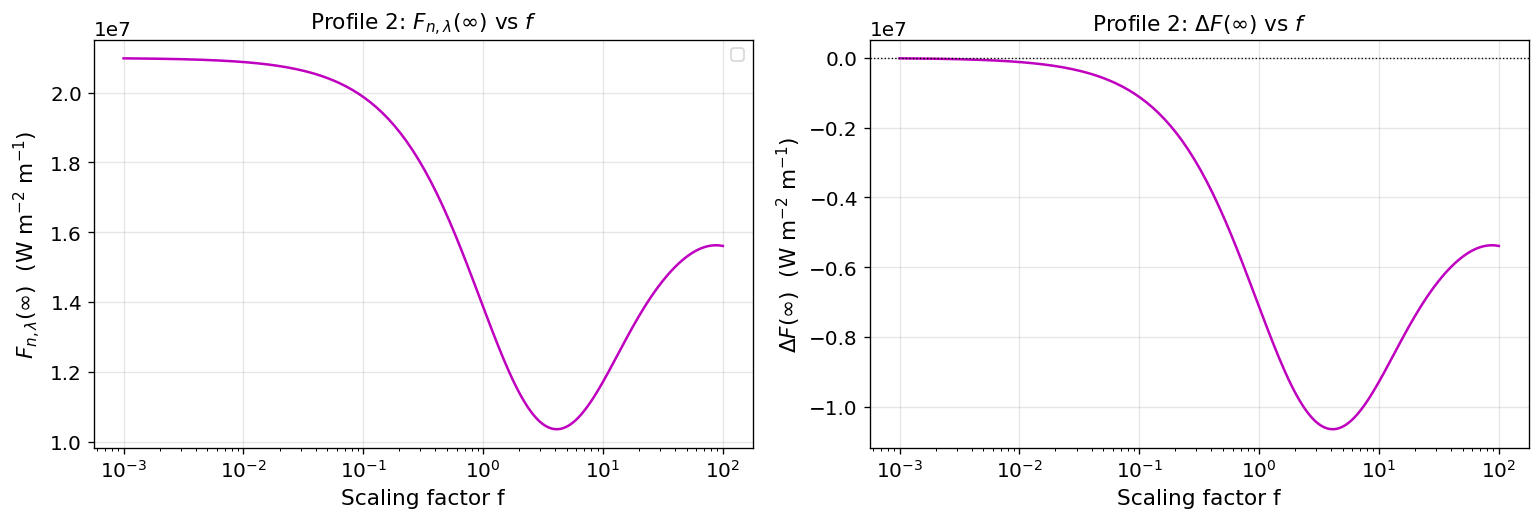

In [40]:
# 3-4. F_n and radiative forcing for profile 2
Fn_2, dF_2 = compute_Fn_and_deltaF(f_sweep, T_profile_2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(f_sweep, Fn_2, 'm-', lw=1.5)
ax1.set_xscale('log')
ax1.set_xlabel('Scaling factor f')
ax1.set_ylabel(r'$F_{n,\lambda}(\infty)$  (W m$^{-2}$ m$^{-1}$)')
ax1.set_title(r'Profile 2: $F_{n,\lambda}(\infty)$ vs $f$')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(f_sweep, dF_2, 'm-', lw=1.5)
ax2.axhline(0, color='k', ls=':', lw=0.8)
ax2.set_xscale('log')
ax2.set_xlabel('Scaling factor f')
ax2.set_ylabel(r'$\Delta F(\infty)$  (W m$^{-2}$ m$^{-1}$)')
ax2.set_title(r'Profile 2: $\Delta F(\infty)$ vs $f$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/profile2.png', bbox_inches='tight')
plt.show()

**3. $F_{n,\lambda}(\infty)$ for all values of $f$:**

The plot on the right shows the OLR at the TOA for profile 2 for a bunch of values of f. 

**5. Explain the shape of $\Delta F(\infty)$ in terms of changes in $W^\uparrow_F(z)$ and $T(z)$:**

In comparison to clear sky in this situation the  $\Delta F(\infty)$ is more complex. In this region for larger values of f the direct radiative forcing of this gas decreases, but the OLR of the gas reaches it's minimum not at the value of the largest f. I think this is because for larger values of f, the weighting function's peak increases with height and in this profile the temperature in higher altiudes begins to increase with hieght. So when the OLR comes mostly from higher altitudes the value will be greater since its emission temperature is pretty high. 



### Temperature Profile 3: Isothermal Atmosphere
$T(z) = 300$ K

/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_34829/3189641021.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  atm_term = np.trapz(np.pi * B_z * W, z)
/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_34829/3014962888.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10)


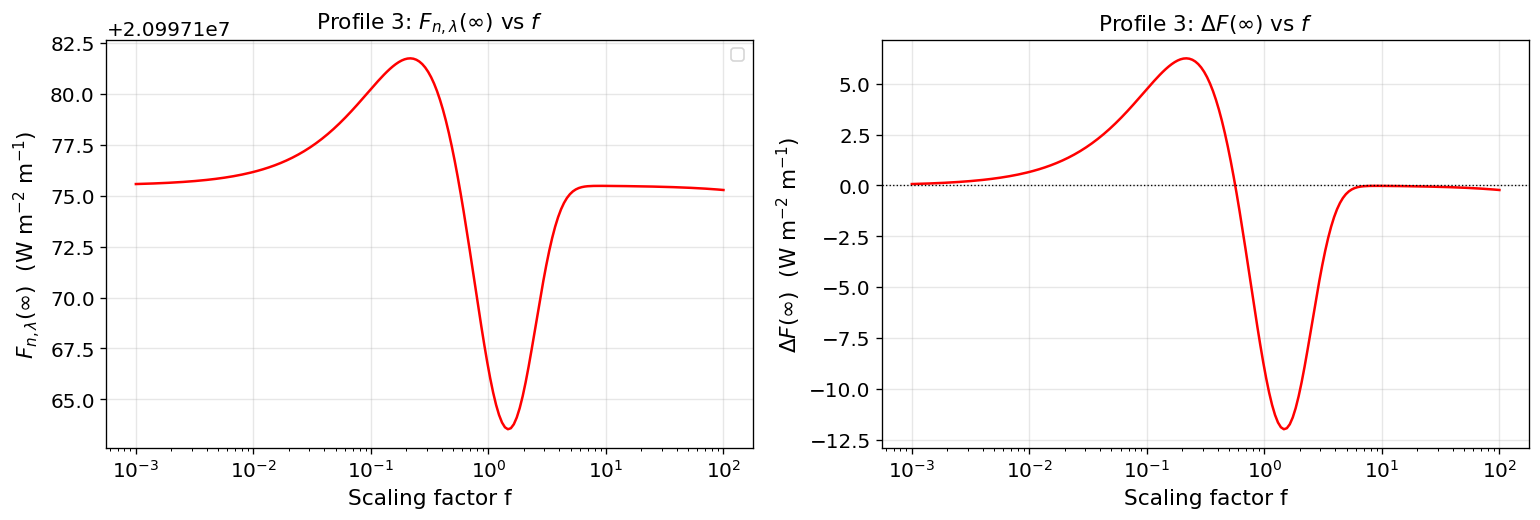

In [41]:
# 3-4. F_n and radiative forcing for isothermal
Fn_iso, dF_iso = compute_Fn_and_deltaF(f_sweep, T_isothermal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(f_sweep, Fn_iso, 'r-', lw=1.5)
ax1.set_xscale('log')
ax1.set_xlabel('Scaling factor f')
ax1.set_ylabel(r'$F_{n,\lambda}(\infty)$  (W m$^{-2}$ m$^{-1}$)')
ax1.set_title(r'Profile 3: $F_{n,\lambda}(\infty)$ vs $f$')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(f_sweep, dF_iso, 'r-', lw=1.5)
ax2.axhline(0, color='k', ls=':', lw=0.8)
ax2.set_xscale('log')
ax2.set_xlabel('Scaling factor f')
ax2.set_ylabel(r'$\Delta F(\infty)$  (W m$^{-2}$ m$^{-1}$)')
ax2.set_title(r'Profile 3: $\Delta F(\infty)$ vs $f$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/profile3_isothermal.png', bbox_inches='tight')
plt.show()

**3. $F_{n,\lambda}(\infty)$ for all values of $f$:**

The plot on the right shows the OLR at the TOA for profile 3, it is a funk shape but if you look at the y axis this profile really does not change much at all compared to the other two. 


**5. Explain the shape of $\Delta F(\infty)$ in terms of changes in $W^\uparrow_F(z)$ and $T(z)$:**

In an isothermal atmosphere there is basically no direct radiative forcing for this gas ie there is no difference from a clear sky OLR and the polluted OLR. This is because, as the weighting function's peak increases with height there is no change in temperaure, which is an important variable in the plank function which gets weighted by the weighting function. I am going to disregard taking about the shape here since idk what is going on aroung f =1, maybe it is just integration in numpy. 

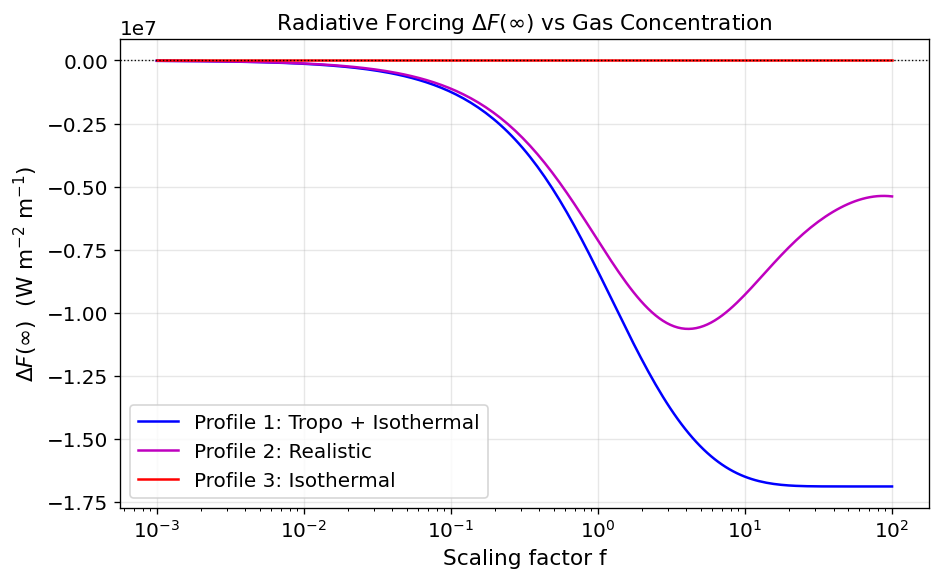

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(f_sweep, dF_1,   'b-',  lw=1.5, label='Profile 1: Tropo + Isothermal')
ax.plot(f_sweep, dF_2,   'm-',  lw=1.5, label='Profile 2: Realistic')
ax.plot(f_sweep, dF_iso, 'r-',  lw=1.5, label='Profile 3: Isothermal')
ax.axhline(0, color='k', ls=':', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Scaling factor f')
ax.set_ylabel(r'$\Delta F(\infty)$  (W m$^{-2}$ m$^{-1}$)')
ax.set_title(r'Radiative Forcing $\Delta F(\infty)$ vs Gas Concentration')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/all_profiles_comparison.png', bbox_inches='tight')
plt.show()

**AI usage statements**
I used claude to help me write the code for this notebook. 
I provided the context etc and the general structure of the code, and claude helped me fill in the functions and plotting code. 
I also used claude to help me use markdown and I asked it to go over my work, especially the calculations of F_n and Delta F, to make sure I was doing it correctly.